<a href="https://colab.research.google.com/github/jipsa1901-prog/MY-ASSIGNMENTS/blob/main/Social_Media_Engagement_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module End Assignment: Social Media Engagement Analytics Using Python
**Dataset:** `social_media_engagement_5000.csv`

Sections: Task 1 Data Import & Setup, Task 2 Data Cleaning, Task 3 Data Exploration, Task 4 Data Wrangling, Task 5 Statistical Analysis, Task 6 Visualization (Matplotlib, Seaborn, Plotly), Final Insights and a one-page summary.

# Task 1: Data Import & Setup

In [ ]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

In [ ]:
# Import the CSV using Pandas
CSV_PATH = "https://raw.githubusercontent.com/GeethaGunasekaran1/Dataset_rep/main/social_media_engagement_5000.csv"

try:
    df = pd.read_csv(CSV_PATH)
except Exception:
    # If GitHub cannot be reached, upload the CSV file manually
    from google.colab import files
    print("Could not load from GitHub. Please upload the CSV file.")
    uploaded = files.upload()
    df = pd.read_csv(next(iter(uploaded)))

print("Shape:", df.shape)
df.head()

Shape: (5000, 19)


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372


In [ ]:
# Standardise column names (lowercase, underscores)
df.columns = (df.columns.str.strip().str.lower()
              .str.replace(r"[^0-9a-z]+", "_", regex=True).str.strip("_"))
print(list(df.columns))

['user_id', 'age', 'gender', 'country', 'post_id', 'post_type', 'post_category', 'likes', 'comments', 'shares', 'watch_time_sec', 'impression_count', 'posted_at', 'follower_count', 'is_verified', 'device_type', 'sentiment', 'hashtags', 'engagement_rate']


In [ ]:
# Map the dataset's column names to the standard names used in this notebook.
# If a column is named differently in your file, add its name to the matching list below.
CANDIDATES = {
    "date": ["date", "post_date", "post_datetime", "timestamp", "created_at", "datetime", "posted_at"],
    "hour": ["hour", "post_hour", "hour_of_day", "time_of_day", "posting_time", "post_time"],
    "post_type": ["post_type", "type", "content_type", "media_type", "post_format"],
    "category": ["category", "content_category", "topic", "post_category"],
    "country": ["country", "location", "region"],
    "gender": ["gender", "user_gender", "sex"],
    "age": ["age", "user_age"],
    "verified": ["verified", "is_verified", "verified_account", "verified_status"],
    "device": ["device", "device_type", "platform_device"],
    "followers": ["followers", "follower_count", "followers_count"],
    "likes": ["likes", "like_count"],
    "comments": ["comments", "comment_count"],
    "shares": ["shares", "share_count"],
    "impressions": ["impressions", "impression_count", "views", "reach"],
    "watch_time": ["watch_time", "watch_time_sec", "watch_time_seconds", "watchtime", "avg_watch_time"],
    "engagement_rate": ["engagement_rate", "eng_rate", "engagement_rate_percent"],
    "sentiment": ["sentiment", "sentiment_label", "post_sentiment"],
    "hashtags": ["hashtags", "hashtag", "hashtag_list", "tags", "hashtag_count"],
}

rename_map = {}
for std, options in CANDIDATES.items():
    for opt in options:
        if opt in df.columns:
            rename_map[opt] = std
            break
df = df.rename(columns=rename_map)

def need(*cols):
    """True only if all the given standard columns exist in the DataFrame."""
    return all(c in df.columns for c in cols)

print("Matched columns:", rename_map)
print("Not found      :", [c for c in CANDIDATES if c not in df.columns])

Matched columns: {'posted_at': 'date', 'post_type': 'post_type', 'post_category': 'category', 'country': 'country', 'gender': 'gender', 'age': 'age', 'is_verified': 'verified', 'device_type': 'device', 'follower_count': 'followers', 'likes': 'likes', 'comments': 'comments', 'shares': 'shares', 'impression_count': 'impressions', 'watch_time_sec': 'watch_time', 'engagement_rate': 'engagement_rate', 'sentiment': 'sentiment', 'hashtags': 'hashtags'}
Not found      : ['hour']


In [ ]:
# Check data types
df.dtypes

,0
user_id,int64
age,float64
gender,object
country,object
post_id,int64
post_type,object
category,object
likes,float64
comments,float64
shares,float64


In [ ]:
# Convert date column to datetime and metric columns to numeric
if need("date"):
    df["date"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")  # dates look like 17-12-2022 (day first)

numeric_cols = ["age", "followers", "likes", "comments", "shares",
                "impressions", "watch_time", "engagement_rate"]
for c in numeric_cols:
    if need(c):
        df[c] = pd.to_numeric(df[c], errors="coerce")

df.dtypes

,0
user_id,int64
age,float64
gender,object
country,object
post_id,int64
post_type,object
category,object
likes,float64
comments,float64
shares,float64


In [ ]:
# Basic NumPy array operations on the likes column
if need("likes"):
    likes_arr = df["likes"].to_numpy(dtype=float)
    print("Array shape      :", likes_arr.shape)
    print("Mean likes       :", np.nanmean(likes_arr).round(2))
    print("Median likes     :", np.nanmedian(likes_arr))
    print("Max / Min likes  :", np.nanmax(likes_arr), "/", np.nanmin(likes_arr))
    print("Std deviation    :", np.nanstd(likes_arr).round(2))
    print("90th percentile  :", np.nanpercentile(likes_arr, 90))
    # Min-max scaling using NumPy
    scaled = (likes_arr - np.nanmin(likes_arr)) / (np.nanmax(likes_arr) - np.nanmin(likes_arr))
    print("First 5 scaled likes:", scaled[:5].round(3))

Array shape      : (5000,)
Mean likes       : 10107.04
Median likes     : 10105.5
Max / Min likes  : 19998.0 / 10.0
Std deviation    : 5789.22
90th percentile  : 18076.1
First 5 scaled likes: [0.35  0.587 0.243 0.267 0.634]


# Task 2: Data Cleaning

### 2.1 Detect missing values

In [ ]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values")
print("\nTotal missing cells:", missing.sum())

Missing values per column:
age          150
gender       150
likes        150
comments     150
shares       150
sentiment    150
dtype: int64

Total missing cells: 900


### 2.2 Duplicate handling

In [ ]:
print("Duplicate rows before:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Duplicate rows after :", df.duplicated().sum())
print("Shape now:", df.shape)

Duplicate rows before: 0
Duplicate rows after : 0
Shape now: (5000, 19)


### 2.3 Data formatting: standardise categories and fix unrealistic values

In [ ]:
# Standardise text categories: trim spaces, fix case
text_cols = [c for c in ["post_type", "category", "country", "gender", "device"] if need(c)]
for c in text_cols:
    df[c] = df[c].str.strip().str.replace(r"\s+", " ", regex=True).str.title()

# Keep common country abbreviations in capitals
if need("country"):
    df["country"] = df["country"].replace({"Uk": "UK", "Usa": "USA", "Uae": "UAE"})

# Standardise gender labels
if need("gender"):
    gender_map = {"m": "Male", "male": "Male", "man": "Male",
                  "f": "Female", "female": "Female", "woman": "Female"}
    g = df["gender"].str.lower()
    df["gender"] = g.map(gender_map)
    df.loc[g.notna() & df["gender"].isna(), "gender"] = "Other"
    print(df["gender"].value_counts(dropna=False))

# Standardise verified flag
if need("verified"):
    vmap = {"true": True, "yes": True, "y": True, "1": True, "1.0": True, "verified": True,
            "false": False, "no": False, "n": False, "0": False, "0.0": False,
            "unverified": False, "not verified": False}
    df["verified"] = df["verified"].astype(str).str.strip().str.lower().map(vmap)

gender
Male      1699
Other     1581
Female    1570
NaN        150
Name: count, dtype: int64


In [ ]:
# Correct unrealistic values: negatives become missing (filled in the next step)
for c in ["likes", "comments", "shares", "impressions", "followers", "watch_time", "engagement_rate"]:
    if need(c):
        n_bad = (df[c] < 0).sum()
        df.loc[df[c] < 0, c] = np.nan
        print(f"{c}: {n_bad} negative values set to NaN")

# Age outside a realistic range (13 to 100) becomes missing
if need("age"):
    n_bad = ((df["age"] < 13) | (df["age"] > 100)).sum()
    df.loc[(df["age"] < 13) | (df["age"] > 100), "age"] = np.nan
    print(f"age: {n_bad} unrealistic values set to NaN")

likes: 0 negative values set to NaN
comments: 0 negative values set to NaN
shares: 0 negative values set to NaN
impressions: 0 negative values set to NaN
followers: 0 negative values set to NaN
watch_time: 0 negative values set to NaN
engagement_rate: 0 negative values set to NaN
age: 0 unrealistic values set to NaN


### 2.4 Handle missing values (median for numeric, mode for categorical, forward/backward fill for dates)

In [ ]:
# Dates: sort, then forward-fill and back-fill
if need("date"):
    df = df.sort_values("date").reset_index(drop=True)
    df["date"] = df["date"].ffill().bfill()

# Hashtags text: missing means no hashtags
if need("hashtags") and not pd.api.types.is_numeric_dtype(df["hashtags"]):
    df["hashtags"] = df["hashtags"].fillna("")

# Numeric columns -> median
for c in df.select_dtypes(include="number").columns:
    df[c] = df[c].fillna(df[c].median())

# Categorical columns -> mode
for c in df.select_dtypes(exclude=["number", "datetime"]).columns:
    if c != "hashtags" and df[c].isna().any():
        df[c] = df[c].fillna(df[c].mode()[0])

# Make verified readable
if need("verified"):
    df["verified"] = df["verified"].map({True: "Verified", False: "Not Verified"})

print("Missing values left:", df.isnull().sum().sum())

Missing values left: 0


In [ ]:
# Likes, comments and shares cannot be higher than impressions
if need("impressions"):
    for c in ["likes", "comments", "shares"]:
        if need(c):
            n_bad = (df[c] > df["impressions"]).sum()
            df[c] = df[c].clip(upper=df["impressions"])
            print(f"{c}: {n_bad} values capped at impressions")

# engagement_rate is a ratio (1.0 = 100%). A value above 1 means more interactions than impressions,
# which is not realistic, so it is capped at 1.
if need("engagement_rate"):
    n_bad = (df["engagement_rate"] > 1).sum()
    df["engagement_rate"] = df["engagement_rate"].clip(upper=1)
    print(f"engagement_rate: {n_bad} values above 1 capped at 1")

likes: 464 values capped at impressions
comments: 65 values capped at impressions
shares: 55 values capped at impressions
engagement_rate: 603 values above 1 capped at 1


### 2.5 Feature cleaning: hashtag count and sentiment labels

In [ ]:
# Extract hashtag count
def count_tags(x):
    x = str(x)
    n = len(re.findall(r"#\w+", x))
    if n:
        return n
    return len([t for t in re.split(r"[,;|\s]+", x) if t])

if need("hashtags"):
    if pd.api.types.is_numeric_dtype(df["hashtags"]):
        df["hashtag_count"] = df["hashtags"].astype(int)
    else:
        df["hashtag_count"] = df["hashtags"].apply(count_tags)
    print(df["hashtag_count"].describe())

# Clean sentiment labels
def clean_sentiment(x):
    if pd.isna(x):
        return x
    x = str(x).strip().lower()
    if x.startswith("pos"):
        return "Positive"
    if x.startswith("neg"):
        return "Negative"
    if x.startswith("neu"):
        return "Neutral"
    return x.title()

if need("sentiment"):
    df["sentiment"] = df["sentiment"].apply(clean_sentiment)
    print(df["sentiment"].value_counts())

count    5000.000000
mean        1.998600
std         0.812853
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         3.000000
Name: hashtag_count, dtype: float64
sentiment
Positive    2513
Neutral     1527
Negative     960
Name: count, dtype: int64


# Task 3: Data Exploration using Pandas

In [ ]:
display(df.head())
display(df.tail())
print("Shape:", df.shape)
print("Columns:", list(df.columns))

,user_id,age,gender,country,post_id,post_type,category,likes,comments,shares,watch_time,impressions,date,followers,verified,device,sentiment,hashtags,engagement_rate,hashtag_count
0,65745,20.0,Female,USA,716149,Video,Education,5780.0,1926.0,1536.0,4193.0,11037.0,2022-01-01,2342.0,Not Verified,Tablet,Positive,#fun,0.837365,1
1,73232,58.0,Male,Brazil,763662,Video,Lifestyle,10924.0,992.0,1461.0,2174.0,11361.0,2022-01-01,712234.0,Not Verified,Tablet,Negative,#fun,1.000000,1
2,16629,50.0,Female,France,916929,Video,Tech,1334.0,243.0,1334.0,6385.0,1334.0,2022-01-01,357021.0,Not Verified,Mobile,Neutral,#foodie #reels #love,1.000000,3
3,19446,54.0,Female,India,106028,Reel,Fashion,9723.0,248.0,1817.0,5305.0,92434.0,2022-01-01,626156.0,Not Verified,Tablet,Positive,#music,0.127529,1
4,97508,48.0,Male,Australia,155313,Text,Lifestyle,4000.0,2900.0,714.0,1490.0,8166.0,2022-01-01,74642.0,Not Verified,Mobile,Negative,#fashion #travel,0.932403,2


,user_id,age,gender,country,post_id,post_type,category,likes,comments,shares,watch_time,impressions,date,followers,verified,device,sentiment,hashtags,engagement_rate,hashtag_count
4995,43933,31.0,Male,Australia,247089,Video,Fitness,15252.0,177.0,836.0,6567.0,59124.0,2023-12-31,769998.0,Not Verified,Desktop,Positive,#love,0.275100,1
4996,87275,27.0,Female,Germany,875299,Image,Fitness,12378.0,2613.0,1138.0,3161.0,99489.0,2023-12-31,276458.0,Verified,Desktop,Positive,#music,0.162118,1
4997,33793,44.0,Female,Germany,530898,Video,Food,328.0,328.0,328.0,472.0,328.0,2023-12-31,667588.0,Not Verified,Tablet,Neutral,#fun,1.000000,1
4998,52604,59.0,Female,Canada,608594,Video,Tech,1049.0,751.0,1046.0,1616.0,65636.0,2023-12-31,749628.0,Not Verified,Mobile,Positive,#fun #fitness #reels,0.043360,3
4999,86367,52.0,Other,UAE,601817,Reel,Fitness,10486.0,774.0,628.0,1886.0,88021.0,2023-12-31,389128.0,Not Verified,Desktop,Neutral,#travel #fashion #tech,0.135059,3


Shape: (5000, 20)
Columns: ['user_id', 'age', 'gender', 'country', 'post_id', 'post_type', 'category', 'likes', 'comments', 'shares', 'watch_time', 'impressions', 'date', 'followers', 'verified', 'device', 'sentiment', 'hashtags', 'engagement_rate', 'hashtag_count']


In [ ]:
df.info()
print()
print(df.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   user_id          5000 non-null   int64         
 1   age              5000 non-null   float64       
 2   gender           5000 non-null   object        
 3   country          5000 non-null   object        
 4   post_id          5000 non-null   int64         
 5   post_type        5000 non-null   object        
 6   category         5000 non-null   object        
 7   likes            5000 non-null   float64       
 8   comments         5000 non-null   float64       
 9   shares           5000 non-null   float64       
 10  watch_time       5000 non-null   float64       
 11  impressions      5000 non-null   float64       
 12  date             5000 non-null   datetime64[ns]
 13  followers        5000 non-null   float64       
 14  verified         5000 non-null   object 

In [ ]:
df.describe()

,user_id,age,post_id,likes,comments,shares,watch_time,impressions,date,followers,engagement_rate,hashtag_count
count,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000,5000.000000,5000.000000,5000.000000
mean,54561.890800,38.440400,548042.909000,9457.73310,1489.343400,995.590400,4014.503200,50013.732800,2022-12-28 13:21:30.240000,393698.224800,0.371312,1.998600
min,10055.000000,13.000000,100068.000000,10.00000,0.000000,0.000000,0.000000,105.000000,2022-01-01 00:00:00,87.000000,0.006363,1.000000
25%,32309.500000,26.000000,322543.500000,4561.25000,765.000000,501.000000,2017.750000,24988.250000,2022-07-03 18:00:00,194480.000000,0.145781,1.000000
50%,54374.500000,38.000000,548077.500000,9382.00000,1497.000000,1012.000000,4034.500000,49934.500000,2022-12-27 00:00:00,388982.000000,0.253896,2.000000
75%,77180.500000,51.000000,771574.500000,14155.75000,2227.250000,1470.000000,6020.250000,74662.250000,2023-06-28 00:00:00,589744.250000,0.504794,3.000000
max,99963.000000,64.000000,999455.000000,19998.00000,2999.000000,1999.000000,7998.000000,99995.000000,2023-12-31 00:00:00,799533.000000,1.000000,3.000000
std,26090.370121,14.687151,260646.957267,5667.38605,857.357127,570.213323,2308.096459,28844.939104,NaN,230927.884535,0.304657,0.812853


In [ ]:
# Categorical distributions
cat_cols = [c for c in ["post_type", "category", "country", "gender", "device", "verified", "sentiment"] if need(c)]
for c in cat_cols:
    print(f"--- {c} ---")
    print("Unique values:", df[c].unique())
    print("Number of unique:", df[c].nunique())
    print(df[c].value_counts())
    print()

--- post_type ---
Unique values: ['Video' 'Reel' 'Text' 'Image']
Number of unique: 4
post_type
Reel     1283
Image    1247
Text     1245
Video    1225
Name: count, dtype: int64

--- category ---
Unique values: ['Education' 'Lifestyle' 'Tech' 'Fashion' 'Fitness' 'Music' 'Travel'
 'Food']
Number of unique: 8
category
Fitness      675
Tech         665
Music        635
Education    631
Lifestyle    607
Travel       600
Fashion      594
Food         593
Name: count, dtype: int64

--- country ---
Unique values: ['USA' 'Brazil' 'France' 'India' 'Australia' 'UK' 'UAE' 'Canada' 'Germany'
 'Japan']
Number of unique: 10
country
India        535
Canada       513
Brazil       504
UAE          503
USA          501
France       496
UK           493
Australia    493
Germany      490
Japan        472
Name: count, dtype: int64

--- gender ---
Unique values: ['Female' 'Male' 'Other']
Number of unique: 3
gender
Male      1849
Other     1581
Female    1570
Name: count, dtype: int64

--- device ---
Unique v

In [ ]:
# Correlation matrix for numeric fields
num_feats = [c for c in ["age", "followers", "likes", "comments", "shares", "impressions",
                         "watch_time", "engagement_rate", "hashtag_count"] if need(c)]
df[num_feats].corr().round(2)

,age,followers,likes,comments,shares,impressions,watch_time,engagement_rate,hashtag_count
age,1.00,-0.02,-0.03,-0.01,0.01,0.01,0.01,-0.02,0.01
followers,-0.02,1.00,-0.03,-0.01,-0.01,-0.02,0.00,-0.00,0.01
likes,-0.03,-0.03,1.00,0.01,0.02,0.19,0.00,0.16,-0.00
comments,-0.01,-0.01,0.01,1.00,0.02,0.02,-0.02,0.03,-0.01
shares,0.01,-0.01,0.02,0.02,1.00,0.02,0.02,0.03,0.01
impressions,0.01,-0.02,0.19,0.02,0.02,1.00,-0.00,-0.78,-0.00
watch_time,0.01,0.00,0.00,-0.02,0.02,-0.00,1.00,0.01,-0.02
engagement_rate,-0.02,-0.00,0.16,0.03,0.03,-0.78,0.01,1.00,-0.01
hashtag_count,0.01,0.01,-0.00,-0.01,0.01,-0.00,-0.02,-0.01,1.00


In [ ]:
# groupby summaries
if need("post_type", "likes"):
    display(df.groupby("post_type")["likes"].mean().round(2).sort_values(ascending=False).to_frame("avg_likes"))
if need("country", "impressions"):
    display(df.groupby("country")["impressions"].sum().sort_values(ascending=False).to_frame("total_impressions"))
if need("category", "engagement_rate"):
    display(df.groupby("category")["engagement_rate"].mean().round(2).sort_values(ascending=False).to_frame("avg_engagement_rate"))

,avg_likes
post_type,
Reel,9513.72
Video,9451.90
Image,9447.67
Text,9415.86


,total_impressions
country,
India,28067377.0
USA,25683200.0
France,25656926.0
UK,25201861.0
Canada,24984716.0
Brazil,24793360.0
UAE,24610992.0
Australia,23834767.0
Germany,23816649.0


,avg_engagement_rate
category,
Education,0.38
Fitness,0.38
Music,0.38
Lifestyle,0.37
Tech,0.37
Travel,0.37
Food,0.36
Fashion,0.36


# Task 4: Data Wrangling

In [ ]:
# New fields: engagement_score, log-transformed metrics
df["engagement_score"] = df["likes"] + df["comments"] + df["shares"]

if not need("engagement_rate") and need("impressions"):
    df["engagement_rate"] = df["engagement_score"] / df["impressions"] * 100

for c in ["likes", "impressions", "followers"]:
    if need(c):
        df[f"log_{c}"] = np.log1p(df[c])

# Hour of posting (from the date column if there is no separate hour column)
if not need("hour") and need("date") and df["date"].dt.hour.nunique() > 1:
    df["hour"] = df["date"].dt.hour

df[["likes", "comments", "shares", "engagement_score"]].head()

,likes,comments,shares,engagement_score
0,5780.0,1926.0,1536.0,9242.0
1,10924.0,992.0,1461.0,13377.0
2,1334.0,243.0,1334.0,2911.0
3,9723.0,248.0,1817.0,11788.0
4,4000.0,2900.0,714.0,7614.0


In [ ]:
# merge: add the country-level average engagement rate back to every row
if need("country", "engagement_rate"):
    country_avg = (df.groupby("country")["engagement_rate"].mean().round(2)
                   .reset_index().rename(columns={"engagement_rate": "country_avg_engagement_rate"}))
    df = df.merge(country_avg, on="country", how="left")
    display(df[["country", "engagement_rate", "country_avg_engagement_rate"]].head())

,country,engagement_rate,country_avg_engagement_rate
0,USA,0.837365,0.36
1,Brazil,1.000000,0.38
2,France,1.000000,0.37
3,India,0.127529,0.34
4,Australia,0.932403,0.39


In [ ]:
# concat: stack two summary tables side by side
if need("post_type", "sentiment", "engagement_score"):
    a = df.groupby("post_type")["engagement_score"].mean().round(2).rename("avg_score_by_post_type")
    b = df.groupby("sentiment")["engagement_score"].mean().round(2).rename("avg_score_by_sentiment")
    display(pd.concat([a, b], axis=1))

,avg_score_by_post_type,avg_score_by_sentiment
Image,11974.57,NaN
Reel,11985.75,NaN
Text,11903.06,NaN
Video,11905.32,NaN
Negative,NaN,11879.95
Neutral,NaN,11794.19
Positive,NaN,12056.84


In [ ]:
# groupby summaries by post_type, country and sentiment
metrics = [c for c in ["likes", "comments", "shares", "impressions", "engagement_score", "engagement_rate"] if need(c)]
for g in ["post_type", "country", "sentiment"]:
    if need(g):
        print(f"=== Average metrics by {g} ===")
        display(df.groupby(g)[metrics].mean().round(2))

=== Average metrics by post_type ===


,likes,comments,shares,impressions,engagement_score,engagement_rate
post_type,,,,,,
Image,9447.67,1513.93,1012.97,49727.42,11974.57,0.37
Reel,9513.72,1494.95,977.08,50462.60,11985.75,0.36
Text,9415.86,1484.95,1002.25,49987.22,11903.06,0.38
Video,9451.90,1462.91,990.51,49862.01,11905.32,0.38


=== Average metrics by country ===


,likes,comments,shares,impressions,engagement_score,engagement_rate
country,,,,,,
Australia,9440.93,1467.44,1013.90,48346.38,11922.26,0.39
Brazil,9302.80,1475.63,997.99,49193.17,11776.42,0.38
Canada,9425.94,1539.64,987.75,48703.15,11953.32,0.38
France,9570.52,1459.17,1042.85,51727.67,12072.54,0.37
Germany,9632.63,1526.98,972.60,48605.41,12132.22,0.38
India,9506.57,1485.00,1030.01,52462.39,12021.58,0.34
Japan,9459.55,1511.22,956.43,49616.14,11927.19,0.38
UAE,9288.72,1523.69,978.56,48928.41,11790.97,0.38
UK,9388.74,1448.98,978.98,51119.39,11816.70,0.36


=== Average metrics by sentiment ===


,likes,comments,shares,impressions,engagement_score,engagement_rate
sentiment,,,,,,
Negative,9378.53,1500.25,1001.18,50191.96,11879.95,0.38
Neutral,9288.90,1515.86,989.43,49515.97,11794.19,0.37
Positive,9590.58,1469.06,997.20,50248.11,12056.84,0.37


# Task 5: Statistical Analysis

In [ ]:
stat_cols = [c for c in ["likes", "comments", "shares", "watch_time", "engagement_rate", "followers"] if need(c)]
rows = {}
for c in stat_cols:
    s = df[c]
    rows[c] = {
        "mean": s.mean(), "median": s.median(), "mode": s.mode()[0],
        "std": s.std(), "variance": s.var(),
        "p25": s.quantile(0.25), "p50": s.quantile(0.50), "p75": s.quantile(0.75),
        "p90": s.quantile(0.90), "p95": s.quantile(0.95),
        "skewness": s.skew(), "kurtosis": s.kurt(),
    }
stats_table = pd.DataFrame(rows).T.round(2)
stats_table

,mean,median,mode,std,variance,p25,p50,p75,p90,p95,skewness,kurtosis
likes,9457.73,9382.00,10105.5,5667.39,3.211926e+07,4561.25,9382.00,14155.75,17565.1,18892.10,0.12,-1.12
comments,1489.34,1497.00,1497.0,857.36,7.350612e+05,765.00,1497.00,2227.25,2689.0,2858.00,0.02,-1.15
shares,995.59,1012.00,1012.0,570.21,3.251432e+05,501.00,1012.00,1470.00,1790.0,1897.00,-0.00,-1.15
watch_time,4014.50,4034.50,916.0,2308.10,5.327309e+06,2017.75,4034.50,6020.25,7212.1,7577.05,-0.02,-1.20
engagement_rate,0.37,0.25,1.0,0.30,9.000000e-02,0.15,0.25,0.50,1.0,1.00,1.06,-0.19
followers,393698.22,388982.00,497502.0,230927.88,5.332769e+10,194480.00,388982.00,589744.25,717755.9,760174.35,0.04,-1.19


# Task 6: Data Visualization

## Matplotlib

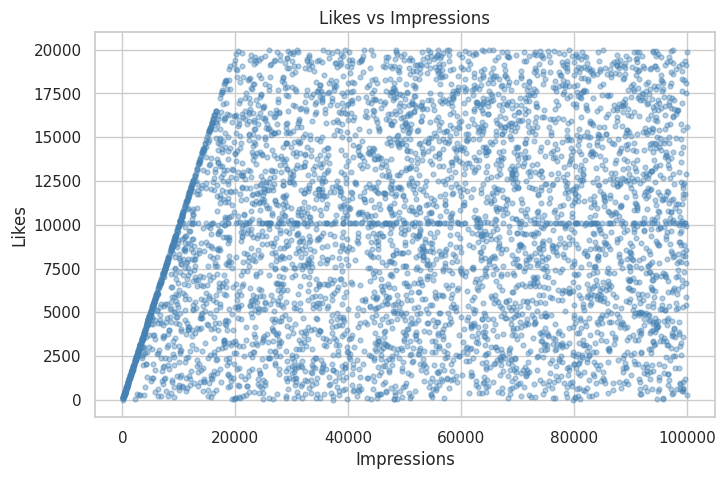

In [ ]:
# 1. Scatter: likes vs impressions
if need("likes", "impressions"):
    plt.figure(figsize=(8, 5))
    plt.scatter(df["impressions"], df["likes"], alpha=0.4, s=12, color="steelblue")
    plt.title("Likes vs Impressions")
    plt.xlabel("Impressions")
    plt.ylabel("Likes")
    plt.show()

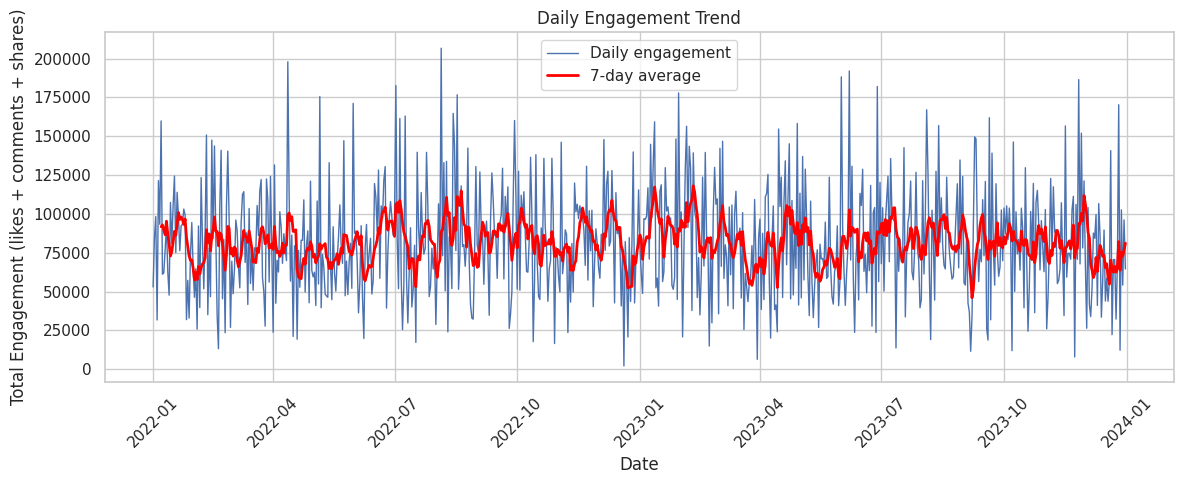

In [ ]:
# 2. Line: daily engagement trend
if need("date", "engagement_score"):
    daily = df.groupby(df["date"].dt.date)["engagement_score"].sum()
    plt.figure(figsize=(12, 5))
    plt.plot(daily.index, daily.values, label="Daily engagement", linewidth=1)
    plt.plot(daily.index, daily.rolling(7).mean().values, label="7-day average", linewidth=2, color="red")
    plt.title("Daily Engagement Trend")
    plt.xlabel("Date")
    plt.ylabel("Total Engagement (likes + comments + shares)")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

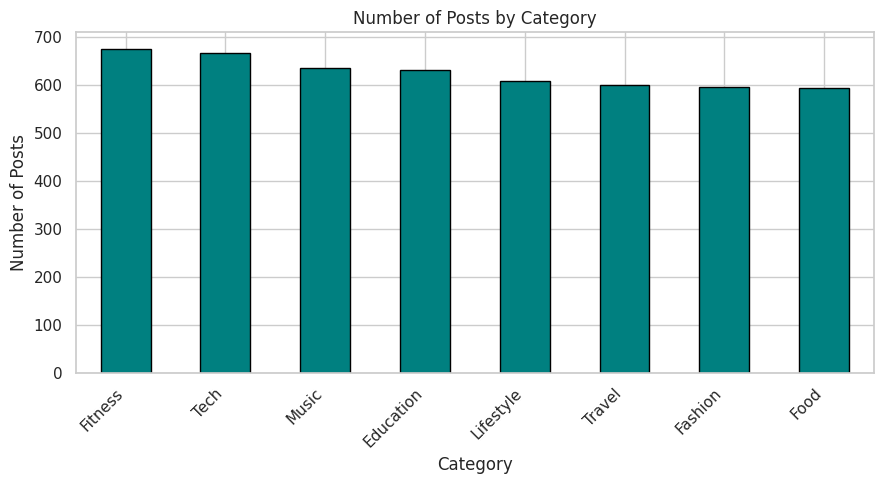

In [ ]:
# 3. Bar: posts by category
if need("category"):
    df["category"].value_counts().plot(kind="bar", figsize=(9, 5), color="teal", edgecolor="black")
    plt.title("Number of Posts by Category")
    plt.xlabel("Category")
    plt.ylabel("Number of Posts")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

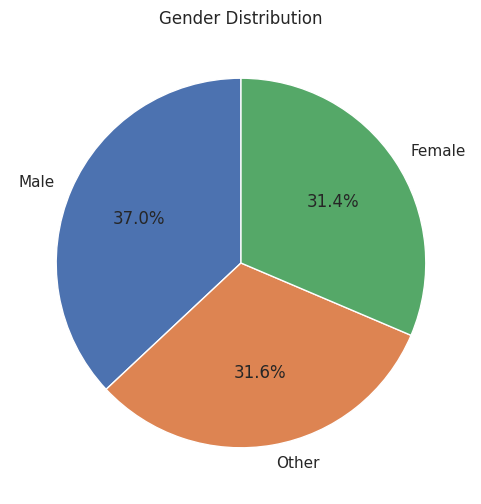

In [ ]:
# 4. Pie: gender distribution
if need("gender"):
    df["gender"].value_counts().plot(kind="pie", autopct="%1.1f%%", figsize=(6, 6), startangle=90)
    plt.title("Gender Distribution")
    plt.ylabel("")
    plt.show()

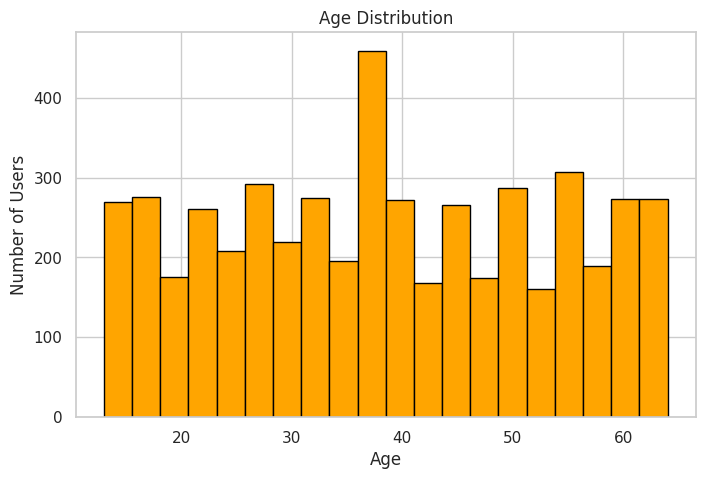

In [ ]:
# 5. Histogram: age
if need("age"):
    plt.figure(figsize=(8, 5))
    plt.hist(df["age"], bins=20, color="orange", edgecolor="black")
    plt.title("Age Distribution")
    plt.xlabel("Age")
    plt.ylabel("Number of Users")
    plt.show()

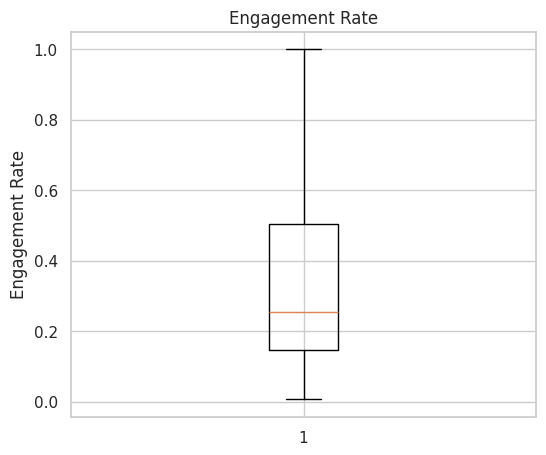

In [ ]:
# 6. Box plot: engagement rate
if need("engagement_rate"):
    plt.figure(figsize=(6, 5))
    plt.boxplot(df["engagement_rate"], vert=True)
    plt.title("Engagement Rate")
    plt.ylabel("Engagement Rate")
    plt.show()

## Seaborn

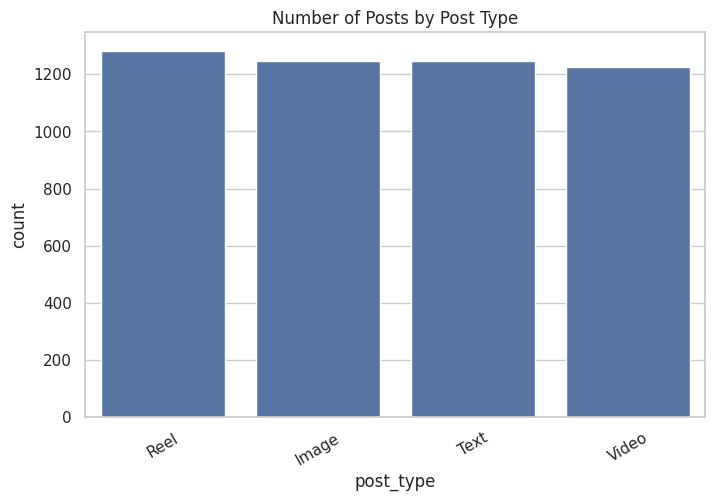

In [ ]:
# 7. Count plot: post type
if need("post_type"):
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x="post_type", order=df["post_type"].value_counts().index)
    plt.title("Number of Posts by Post Type")
    plt.xticks(rotation=30)
    plt.show()

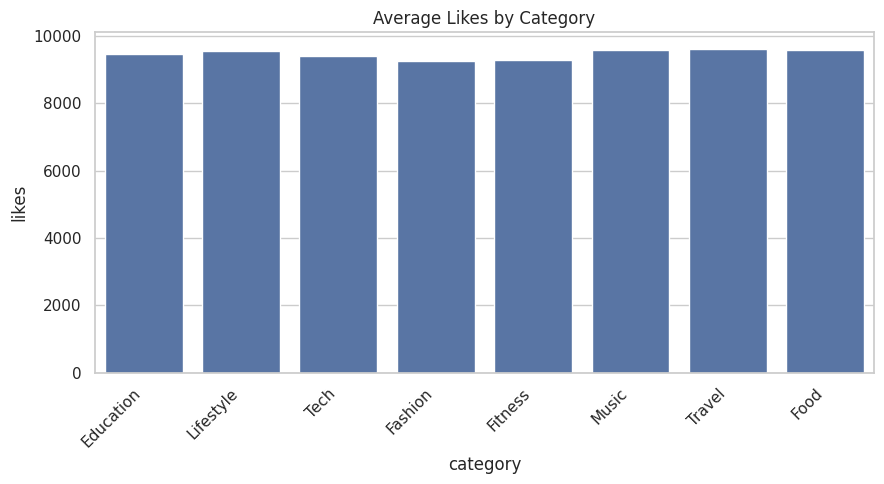

In [ ]:
# 8. Bar plot: average likes by category
if need("category", "likes"):
    plt.figure(figsize=(9, 5))
    sns.barplot(data=df, x="category", y="likes", estimator="mean", errorbar=None)
    plt.title("Average Likes by Category")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

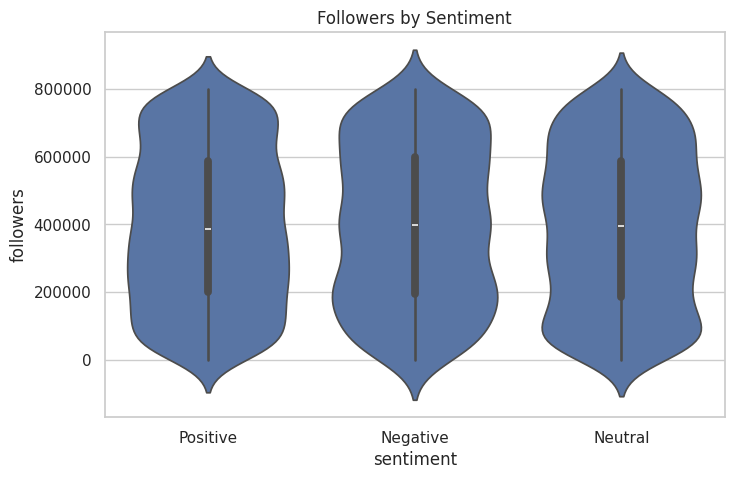

In [ ]:
# 9. Violin: followers vs sentiment
if need("sentiment", "followers"):
    plt.figure(figsize=(8, 5))
    sns.violinplot(data=df, x="sentiment", y="followers")
    plt.title("Followers by Sentiment")
    plt.show()

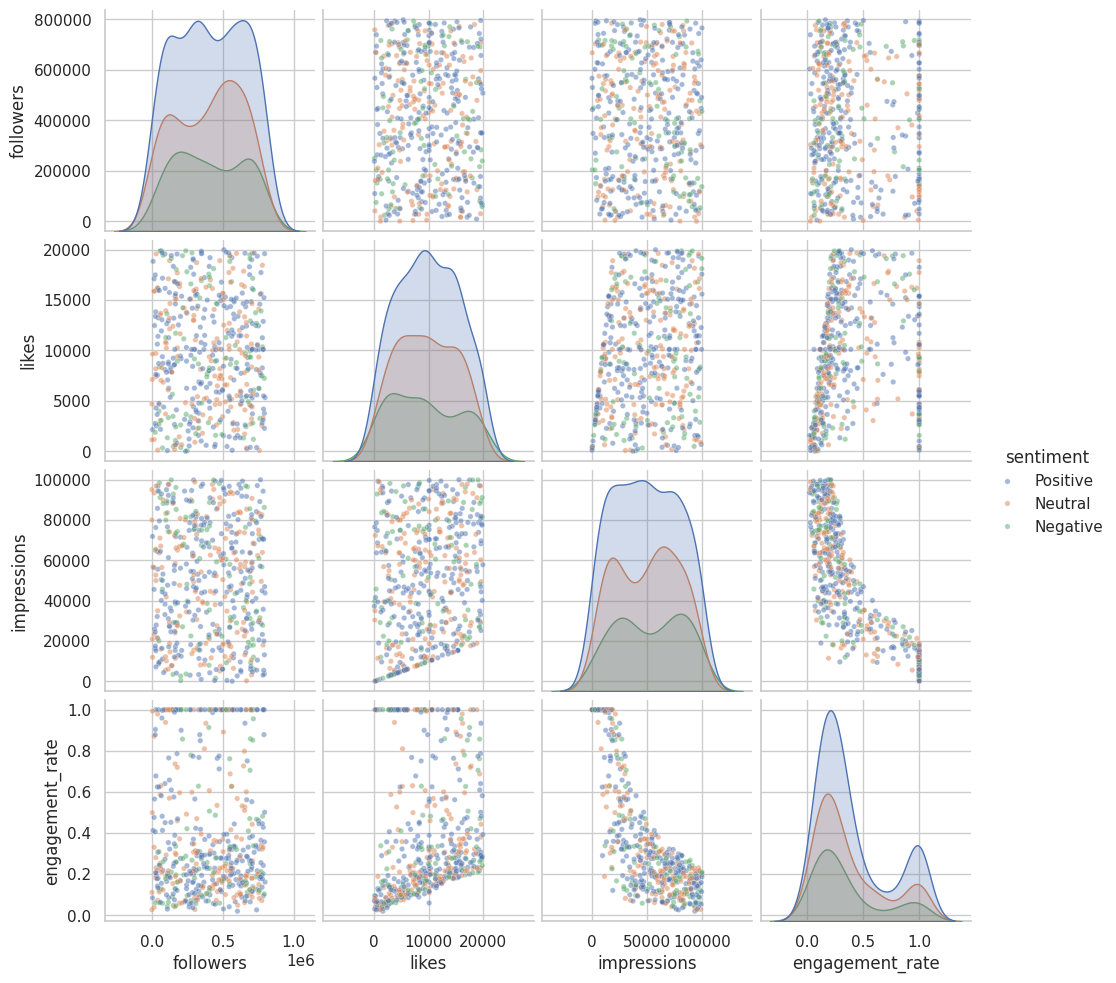

In [ ]:
# 10. Pair plot: numeric features (sample of 500 rows for speed)
pair_vars = [c for c in ["followers", "likes", "impressions", "engagement_rate"] if need(c)]
if len(pair_vars) >= 2:
    hue = "sentiment" if need("sentiment") else None
    sns.pairplot(df.sample(min(500, len(df)), random_state=1), vars=pair_vars, hue=hue,
                 plot_kws={"alpha": 0.5, "s": 15})
    plt.show()

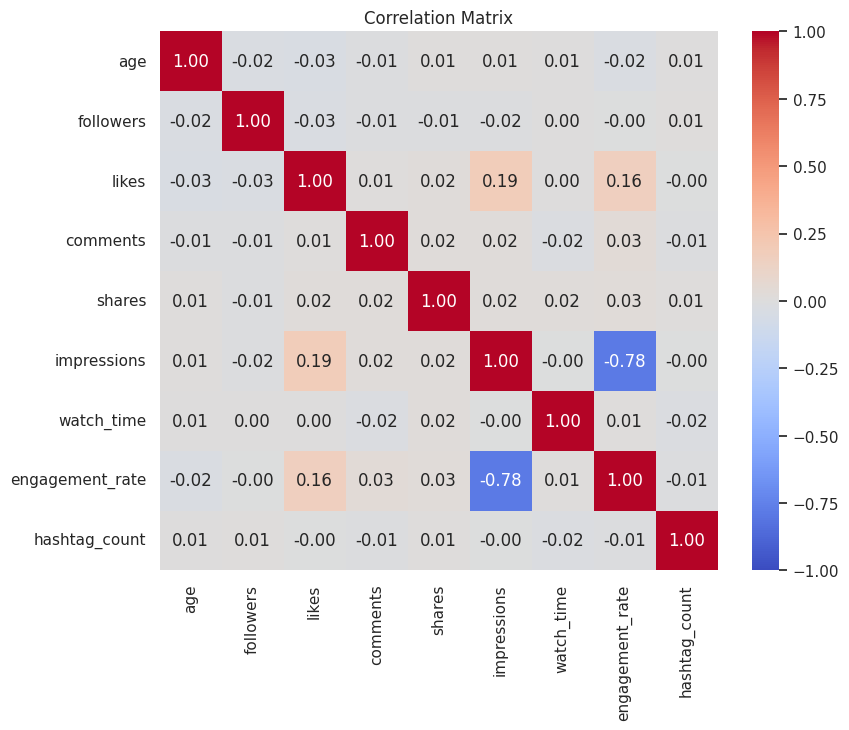

In [ ]:
# 11. Heatmap: correlation matrix
plt.figure(figsize=(9, 7))
sns.heatmap(df[num_feats].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.show()

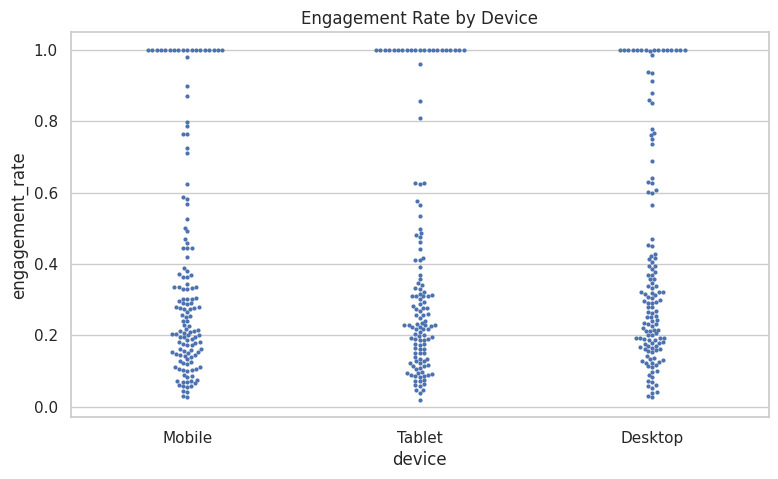

In [ ]:
# 12. Swarm plot: engagement vs device (sample of 400 rows so points stay readable)
if need("device", "engagement_rate"):
    plt.figure(figsize=(9, 5))
    sns.swarmplot(data=df.sample(min(400, len(df)), random_state=1), x="device", y="engagement_rate", size=3)
    plt.title("Engagement Rate by Device")
    plt.show()

## Plotly (Interactive)

In [ ]:
# Interactive line chart: daily engagement
if need("date", "engagement_score"):
    daily_df = df.groupby(df["date"].dt.date)["engagement_score"].sum().reset_index()
    fig = px.line(daily_df, x="date", y="engagement_score", title="Daily Engagement (interactive)")
    fig.show()

In [ ]:
# Interactive bar chart: average engagement rate by country
if need("country", "engagement_rate"):
    bar_df = df.groupby("country")["engagement_rate"].mean().reset_index().sort_values("engagement_rate", ascending=False)
    fig = px.bar(bar_df, x="country", y="engagement_rate", title="Average Engagement Rate by Country",
                 color="engagement_rate")
    fig.show()

In [ ]:
# Interactive bubble chart: impressions vs likes, bubble size = followers
if need("impressions", "likes", "followers"):
    color = "post_type" if need("post_type") else None
    fig = px.scatter(df.sample(min(1000, len(df)), random_state=1), x="impressions", y="likes",
                     size="followers", color=color, opacity=0.6, title="Impressions vs Likes (bubble size = followers)")
    fig.show()

In [ ]:
# Interactive scatter chart: age vs engagement rate
if need("age", "engagement_rate"):
    color = "gender" if need("gender") else None
    fig = px.scatter(df.sample(min(1000, len(df)), random_state=1), x="age", y="engagement_rate",
                     color=color, opacity=0.6, title="Age vs Engagement Rate")
    fig.show()

# Final Insights

In [ ]:
summary = []   # collects the key findings for the one-page summary

## Content Performance

In [ ]:
# Which post types have the highest engagement?
if need("post_type", "engagement_rate"):
    s = df.groupby("post_type")["engagement_rate"].mean().sort_values(ascending=False).round(2)
    display(s.to_frame("avg_engagement_rate"))
    summary.append(f"**Post types:** {s.index[0]} posts have the highest average engagement rate ({s.iloc[0]}), "
                   f"while {s.index[-1]} posts have the lowest ({s.iloc[-1]}).")

# Best-performing content category?
if need("category", "engagement_rate"):
    s = df.groupby("category")["engagement_rate"].mean().sort_values(ascending=False).round(2)
    display(s.to_frame("avg_engagement_rate"))
    summary.append(f"**Categories:** {s.index[0]} is the best-performing category (avg engagement rate {s.iloc[0]}), "
                   f"and {s.index[-1]} is the weakest ({s.iloc[-1]}).")

# Which countries have the highest average engagement rate?
if need("country", "engagement_rate"):
    s = df.groupby("country")["engagement_rate"].mean().sort_values(ascending=False).round(2)
    display(s.head(5).to_frame("avg_engagement_rate"))
    top3 = ", ".join(f"{k} ({v})" for k, v in s.head(3).items())
    summary.append(f"**Countries:** the highest average engagement rates are in {top3}.")

,avg_engagement_rate
post_type,
Text,0.38
Video,0.38
Image,0.37
Reel,0.36


,avg_engagement_rate
category,
Fitness,0.38
Music,0.38
Education,0.38
Lifestyle,0.37
Tech,0.37
Travel,0.37
Fashion,0.36
Food,0.36


,avg_engagement_rate
country,
Australia,0.39
Japan,0.38
UAE,0.38
Germany,0.38
Canada,0.38


## User Trends

In [ ]:
# How does age affect engagement?
if need("age", "engagement_rate"):
    df["age_group"] = pd.cut(df["age"], bins=[12, 17, 24, 34, 44, 54, 100],
                             labels=["13-17", "18-24", "25-34", "35-44", "45-54", "55+"])
    s = df.groupby("age_group", observed=True)["engagement_rate"].mean().round(2)
    display(s.to_frame("avg_engagement_rate"))
    corr = df["age"].corr(df["engagement_rate"])
    trend = "rises" if corr > 0.05 else "falls" if corr < -0.05 else "shows almost no clear change"
    summary.append(f"**Age:** engagement {trend} with age (correlation {corr:.2f}); "
                   f"the most engaged age group is {s.idxmax()} ({s.max()}).")

# Performance difference for verified accounts
if need("verified", "engagement_rate"):
    cols = [c for c in ["engagement_rate", "likes", "followers", "impressions"] if need(c)]
    v = df.groupby("verified")[cols].mean().round(2)
    display(v)
    if {"Verified", "Not Verified"} <= set(v.index):
        d = v.loc["Verified", "engagement_rate"] - v.loc["Not Verified", "engagement_rate"]
        summary.append(f"**Verified accounts:** their average engagement rate is {v.loc['Verified','engagement_rate']} "
                       f"versus {v.loc['Not Verified','engagement_rate']} for non-verified accounts ({d:+.2f}).")

,avg_engagement_rate
age_group,
13-17,0.40
18-24,0.37
25-34,0.37
35-44,0.37
45-54,0.37
55+,0.36


,engagement_rate,likes,followers,impressions
verified,,,,
Not Verified,0.37,9501.21,395042.84,49935.29
Verified,0.35,9051.14,381123.45,50747.34


## Behavioral Insights

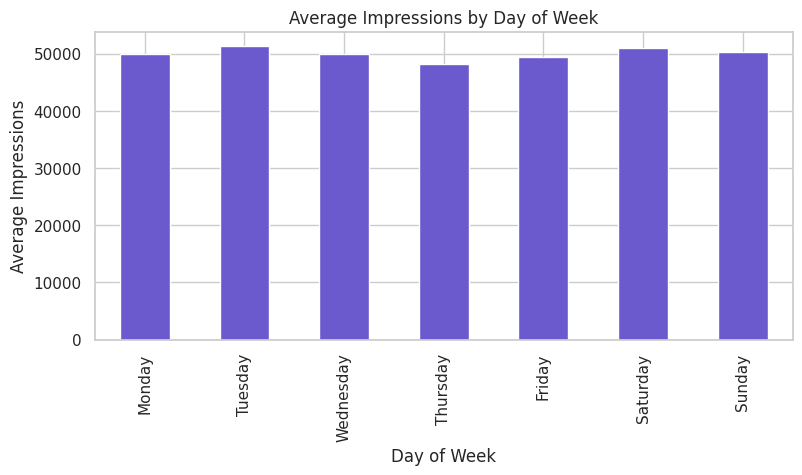

Note: the dataset has no time-of-day information, so day of week was analysed instead.


,avg_watch_time
device,
Mobile,4087.83
Tablet,3979.74
Desktop,3974.79


In [ ]:
# Best time of day for impressions
if need("hour", "impressions"):
    s = df.groupby("hour")["impressions"].mean().round(0)
    plt.figure(figsize=(9, 4))
    s.plot(kind="bar", color="slateblue")
    plt.title("Average Impressions by Hour of Day")
    plt.xlabel("Hour")
    plt.ylabel("Average Impressions")
    plt.show()
    summary.append(f"**Time of day:** posts get the most impressions around hour {s.idxmax()} "
                   f"(avg {int(s.max())}), and the fewest around hour {s.idxmin()} (avg {int(s.min())}).")
elif need("date", "impressions"):
    # The dataset stores only dates (no clock time), so time of day cannot be measured.
    # Day of week and month are used instead.
    order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
    df["day_of_week"] = df["date"].dt.day_name()
    s = df.groupby("day_of_week")["impressions"].mean().reindex(order).round(0)
    plt.figure(figsize=(9, 4))
    s.plot(kind="bar", color="slateblue")
    plt.title("Average Impressions by Day of Week")
    plt.xlabel("Day of Week")
    plt.ylabel("Average Impressions")
    plt.show()
    m = df.groupby(df["date"].dt.month_name())["impressions"].mean().round(0)
    print("Note: the dataset has no time-of-day information, so day of week was analysed instead.")
    summary.append(f"**Timing:** the data has dates only (no clock time), so time of day cannot be measured. "
                   f"By day of week, {s.idxmax()} posts get the most impressions (avg {int(s.max())}) and "
                   f"{s.idxmin()} the fewest (avg {int(s.min())}); by month, {m.idxmax()} is highest.")

# Device type impact on watch time
if need("device", "watch_time"):
    s = df.groupby("device")["watch_time"].mean().sort_values(ascending=False).round(2)
    display(s.to_frame("avg_watch_time"))
    summary.append(f"**Devices:** {s.index[0]} users have the longest average watch time ({s.iloc[0]}), "
                   f"and {s.index[-1]} users the shortest ({s.iloc[-1]}).")

## Sentiment Analysis

In [ ]:
# Which sentiment performs best?
if need("sentiment", "engagement_rate"):
    cols = [c for c in ["likes", "comments", "shares", "engagement_rate", "watch_time"] if need(c)]
    sent = df.groupby("sentiment")[cols].mean().round(2)
    sent["share_of_posts_%"] = (df["sentiment"].value_counts(normalize=True) * 100).round(1)
    display(sent)
    best = sent["engagement_rate"].idxmax()
    summary.append(f"**Sentiment:** {best} posts perform best (avg engagement rate {sent.loc[best,'engagement_rate']}).")

    # Behaviour of negative / neutral posts
    for label in ["Negative", "Neutral"]:
        if label in sent.index:
            diff = sent.loc[label, "engagement_rate"] - sent["engagement_rate"].mean()
            summary.append(f"**{label} posts:** {sent.loc[label,'share_of_posts_%']}% of posts, with an average engagement rate of "
                           f"{sent.loc[label,'engagement_rate']} ({diff:+.2f} versus the average sentiment group).")

,likes,comments,shares,engagement_rate,watch_time,share_of_posts_%
sentiment,,,,,,
Negative,9378.53,1500.25,1001.18,0.38,4054.64,19.2
Neutral,9288.90,1515.86,989.43,0.37,4031.82,30.5
Positive,9590.58,1469.06,997.20,0.37,3988.65,50.3


# One-Page Summary
Run the cell below to generate the summary from the analysis above, then copy it into your submission document.

In [ ]:
# Check how big the differences between groups really are
overall = df["engagement_rate"].mean()
spreads = []
for g in ["post_type", "category", "country", "sentiment", "device"]:
    if need(g):
        m = df.groupby(g)["engagement_rate"].mean()
        spreads.append((m.max() - m.min()) / overall)
head = f"Overall average engagement rate is {overall:.2f} (1.00 = 100% of impressions)."
if spreads and max(spreads) < 0.25:
    head += (" The differences between groups are small (the best and worst groups are within "
             f"{max(spreads)*100:.0f}% of the overall average), so the patterns below are weak and should be read with care.")
summary.insert(0, head)

display(Markdown("## Social Media Engagement Analytics: Key Findings\n\n" + "\n\n".join(summary)))

## Social Media Engagement Analytics: Key Findings

Overall average engagement rate is 0.37 (1.00 = 100% of impressions). The differences between groups are small (the best and worst groups are within 15% of the overall average), so the patterns below are weak and should be read with care.

**Post types:** Text posts have the highest average engagement rate (0.38), while Reel posts have the lowest (0.36).

**Categories:** Fitness is the best-performing category (avg engagement rate 0.38), and Food is the weakest (0.36).

**Countries:** the highest average engagement rates are in Australia (0.39), Japan (0.38), UAE (0.38).

**Age:** engagement shows almost no clear change with age (correlation -0.02); the most engaged age group is 13-17 (0.4).

**Verified accounts:** their average engagement rate is 0.35 versus 0.37 for non-verified accounts (-0.02).

**Timing:** the data has dates only (no clock time), so time of day cannot be measured. By day of week, Tuesday posts get the most impressions (avg 51309) and Thursday the fewest (avg 48119); by month, September is highest.

**Devices:** Mobile users have the longest average watch time (4087.83), and Desktop users the shortest (3974.79).

**Sentiment:** Negative posts perform best (avg engagement rate 0.38).

**Negative posts:** 19.2% of posts, with an average engagement rate of 0.38 (+0.01 versus the average sentiment group).

**Neutral posts:** 30.5% of posts, with an average engagement rate of 0.37 (-0.00 versus the average sentiment group).